In [3]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd


# Load via excel

In [3]:
# Load the Excel file
input_file = '20241008 Benchmark Database.xlsx'  # Replace with your file path
df = pd.read_excel(input_file)


# x.save_to_disk("hellaswag_local/")

# y = datasets.load_dataset(path="hellaswag", data_dir="hellaswag_local/")

# Load via HF

In [6]:
# !pip install datasets

In [ ]:
import os
os.environ['HF_TOKEN'] = 'hf_yourkeyhere'

In [2]:
import datasets
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("rabell/SysEngBench")

# Access the test split
test_split = dataset["test"]

# Convert the test split to a Pandas DataFrame
df = test_split.to_pandas()


d:\lm-eval-post-processing-results\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def explode_incose_handbook_category(df):
    # Fill NaN values with empty strings to prevent issues during splitting
    df = df.copy()
    df.loc[:, 'INCOSE Handbook Category'] = df['INCOSE Handbook Category'].fillna('')
    
    # Explode 'INCOSE Handbook Category' by splitting on newline characters
    incose_expanded = df['INCOSE Handbook Category'].str.split('\n').explode()

    # Create a new DataFrame with expanded rows dynamically copying all columns
    incose_expanded_df = df.loc[incose_expanded.index].copy()
    incose_expanded_df['INCOSE Handbook Category'] = incose_expanded.values

    # Split 'INCOSE Handbook Category' into 'INCOSE Category' and 'INCOSE Sub-Category'
    incose_expanded_df[['INCOSE Category', 'INCOSE Sub-Category']] = incose_expanded_df['INCOSE Handbook Category'] \
        .str.extract(r'INCOSEHandbook/([^/]+)/(.+)')

    return incose_expanded_df.reset_index(drop=True)


expanded_df = explode_incose_handbook_category(df)
print(expanded_df)

      Question ID                  Tags  \
0               1  Introduction to risk   
1               2  Introduction to risk   
2               2  Introduction to risk   
3               3  Introduction to risk   
4               4  Introduction to risk   
...           ...                   ...   
1205         1140      Design Standards   
1206         1141      Design Standards   
1207         1142      Design Standards   
1208         1143      Design Standards   
1209         1144      Design Standards   

                               INCOSE Handbook Category  \
0     INCOSEHandbook/Systems Engineering Overview/Sy...   
1     INCOSEHandbook/Systems Engineering Overview/Sy...   
2     INCOSEHandbook/Technical Management Processes/...   
3     INCOSEHandbook/Systems Engineering Overview/Sy...   
4     INCOSEHandbook/Systems Engineering Overview/Sy...   
...                                                 ...   
1205  INCOSEHandbook/Specialty Engineering Activitie...   
1206  INCOS

# Outputting QTY by Category and Subcat

In [4]:
# Calculate total unique MCQs
total_unique_mcqs = expanded_df['Question ID'].nunique()

# Number of MCQs by INCOSE category
mcqs_by_category = expanded_df.groupby('INCOSE Category')['Question ID'].nunique()

# Number of MCQs by INCOSE sub-category
mcqs_by_subcategory = expanded_df.groupby('INCOSE Sub-Category')['Question ID'].nunique()

# Display results
print("Total Unique MCQs:", total_unique_mcqs)
print("\nMCQs by INCOSE Category:\n", mcqs_by_category)
print("\nMCQs by INCOSE Sub-Category:\n", mcqs_by_subcategory)


Total Unique MCQs: 1144

MCQs by INCOSE Category:
 INCOSE Category
Cross-Cutting Systems Engineering Methods    276
Lifecycle Stages                             187
Specialty Engineering Activities             419
Systems Engineering Overview                 107
Technical Management Processes               110
Technical Processes                          104
Name: Question ID, dtype: int64

MCQs by INCOSE Sub-Category:
 INCOSE Sub-Category
Application and Value of Systems Engineering                               18
Architecture Definition Process                                            18
Configuration and Information Management                                   43
Cost Modeling                                                              41
Decision Management, Analysis of Alternatives, and Tradespace Analysis     39
Defense Acquisition Life Cycle/Lifecycle Phases                            95
Defense Acquisition Life Cycle/Milestones and Reviews                      57
Electromag

In [5]:
#### NEXT 2 CELLS ARE IN WORK.... $$$$
# Save to a new Excel file
output_file = 'parsed_incose_handbook.xlsx'  # Replace with your desired output path
incose_expanded_df.to_excel(output_file, index=False)

print(f"Parsed data saved to {output_file}")


NameError: name 'incose_expanded_df' is not defined

In [25]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Alignment

# Data: MCQs by INCOSE Category and Sub-Category
mcqs_by_category = {
    "Cross-Cutting Systems Engineering Methods": {
        "Subcategories": {
            "Application and Value of Systems Engineering": 18,
            "Systems Science and Thinking": 22,
        }
    },
    "Lifecycle Stages": {
        "Subcategories": {
            "Generic Life Cycle Stages": 35,
            "Defense Acquisition Life Cycle/Lifecycle Phases": 95,
            "Defense Acquisition Life Cycle/Milestones and Reviews": 57,
        }
    },
    "Specialty Engineering Activities": {
        "Subcategories": {
            "Electromagnetic Compatibility": 41,
            "System Safety Engineering": 9,
            "Usability and Human Systems Integration": 96,
        }
    },
}

# Create a new Excel workbook
wb = Workbook()
ws = wb.active
ws.title = "MCQ Data"

# Add headers
headers = ["INCOSE Category", "INCOSE Sub-Category", "Number of MCQs"]
ws.append(headers)

# Set alignment for headers
for col in ws.iter_cols(min_row=1, max_row=1, min_col=1, max_col=3):
    for cell in col:
        cell.alignment = Alignment(horizontal="center", vertical="center")

# Add data with merged cells for categories
row = 2
for category, data in mcqs_by_category.items():
    subcategories = data["Subcategories"]
    start_row = row
    for subcategory, count in subcategories.items():
        ws.append([None, subcategory, count])
        row += 1
    # Merge cells for the category column
    ws.merge_cells(start_row=start_row, start_column=1, end_row=row - 1, end_column=1)
    ws.cell(row=start_row, column=1).value = category
    ws.cell(row=start_row, column=1).alignment = Alignment(vertical="center")

# Save the workbook
output_file = "MCQ_Categorized.xlsx"
wb.save(output_file)

print(f"Excel file saved as {output_file}")


Excel file saved as MCQ_Categorized.xlsx


# Visualizing the Question Distributions - Pie Chart

In [2]:
## make a table for questions by topic

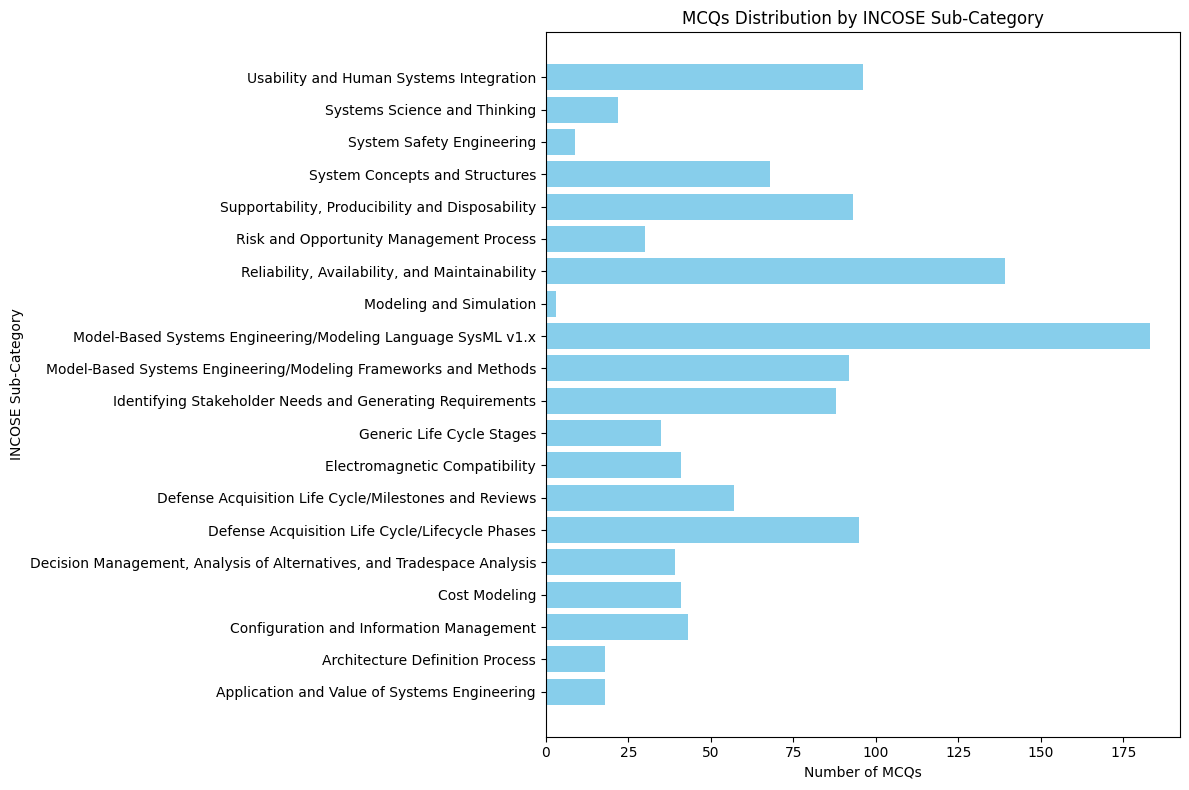

In [48]:
# Extract categories and values from the pandas Series
categories = mcqs_by_category.index.tolist()  # Use .index for the labels
subcategories = mcqs_by_subcategory.index.tolist()  # Use .index for the labels
categories_values = mcqs_by_category.values.tolist()    # Use .values for the data
subcategories_values = mcqs_by_subcategory.values.tolist()    # Use .values for the data

plt.figure(figsize=(12, 8))
plt.barh(subcategories, subcategories_values, color="skyblue")
plt.xlabel("Number of MCQs")
plt.ylabel("INCOSE Sub-Category")
plt.title("MCQs Distribution by INCOSE Sub-Category")
plt.tight_layout()
plt.show()


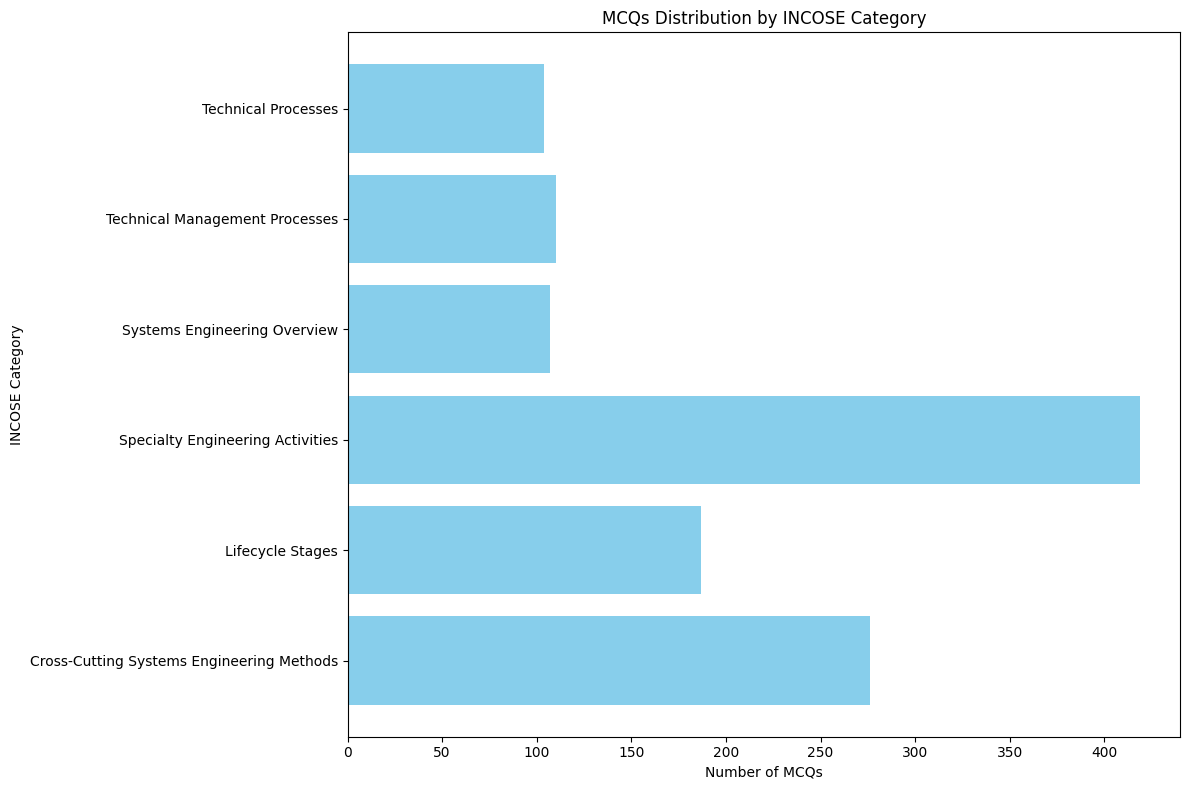

In [49]:
# Create a horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(categories, categories_values, color="skyblue")
plt.xlabel("Number of MCQs")
plt.ylabel("INCOSE Category")
plt.title("MCQs Distribution by INCOSE Category")
plt.tight_layout()
plt.show()

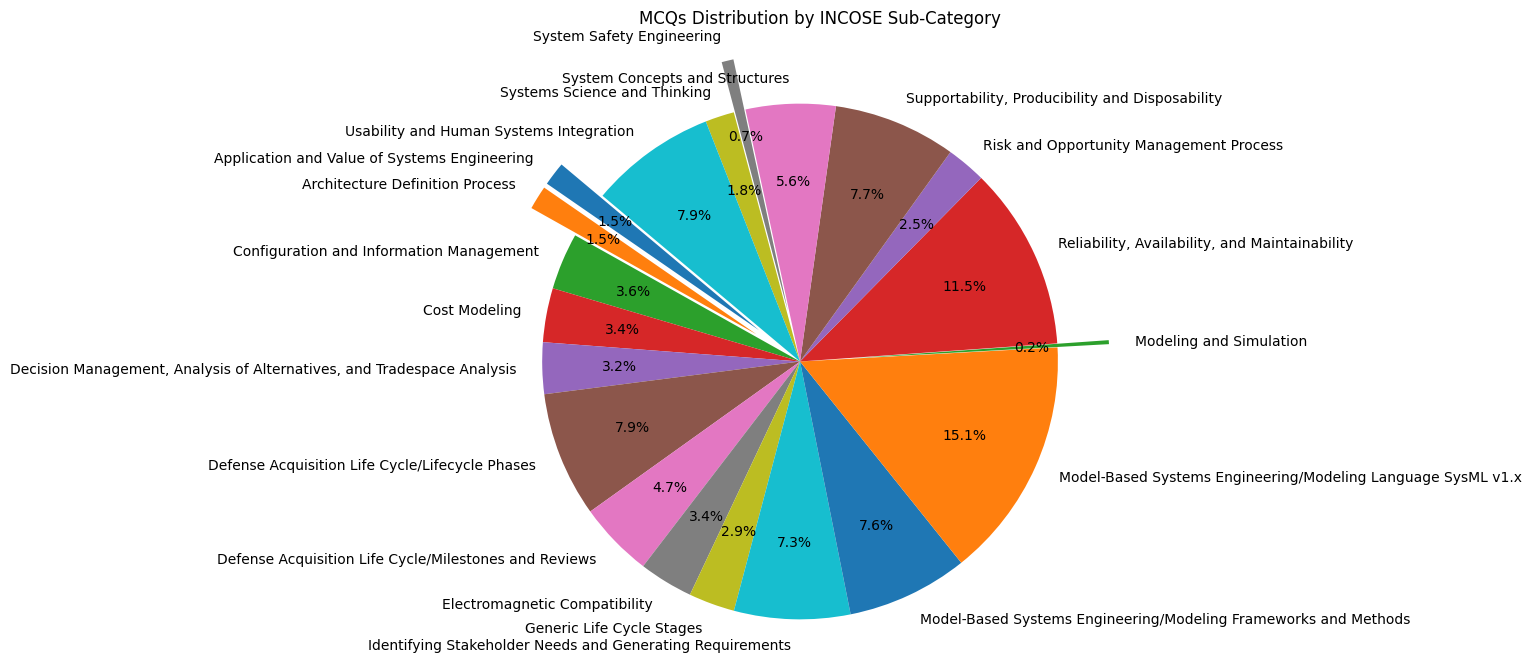

In [65]:
explode = [0.2 if v < max(subcategories_values) * 0.1 else 0 for v in subcategories_values]  # Explode smaller slices
plt.figure(figsize=(12, 8))
plt.pie(
    values, 
    labels=subcategories, 
    autopct='%1.1f%%', 
    startangle=140, 
    explode=explode,
    pctdistance=0.7,  # Distance of percentage text
)
plt.title("MCQs Distribution by INCOSE Sub-Category")
plt.axis("equal")
plt.show()


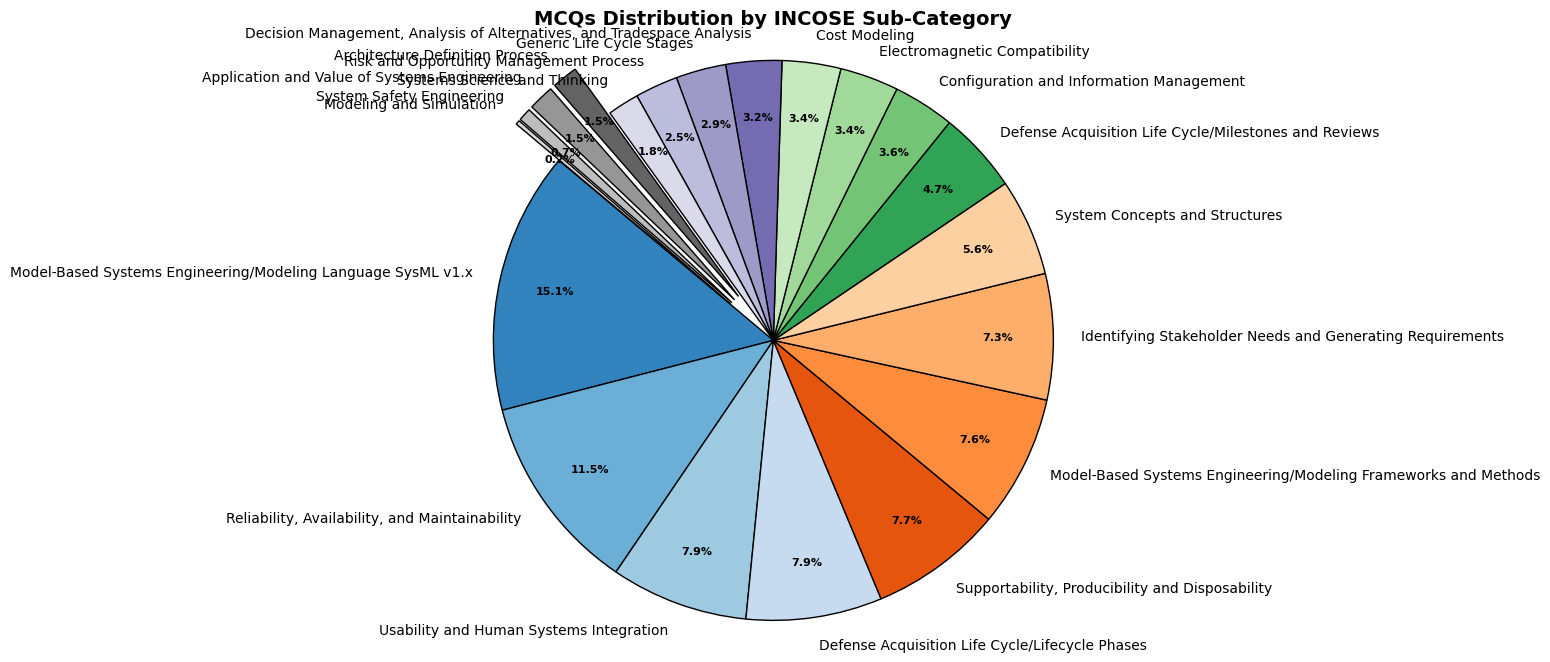

In [21]:
import matplotlib.pyplot as plt

# Group the data by 'INCOSE Sub-Category' and count occurrences
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Data for the pie chart
subcategories = subcategory_counts.index
subcategories_values = subcategory_counts.values

# Dynamically explode smaller slices (consistent with your request)
explode = [0.2 if v < max(subcategories_values) * 0.1 else 0 for v in subcategories_values]

# Create the pie chart
plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(
    subcategories_values, 
    labels=subcategories, 
    autopct='%1.1f%%',  # Display percentages
    startangle=140,  # Start angle for better orientation
    explode=explode,  # Explode smaller slices
    pctdistance=0.8,  # Distance of percentage text
    labeldistance=1.1,  # Distance of labels from the center
    colors=plt.cm.tab20c.colors[:len(subcategories)],  # Use a colormap for diverse colors
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'},  # Add an outline for clarity
)

# Style the text
plt.setp(autotexts, size=8, weight="bold")
plt.setp(texts, size=10)

# Add a title
plt.title("MCQs Distribution by INCOSE Sub-Category", fontsize=14, weight='bold')

# Equal aspect ratio ensures the pie is drawn as a circle
plt.axis("equal")

# Show the plot
plt.show()


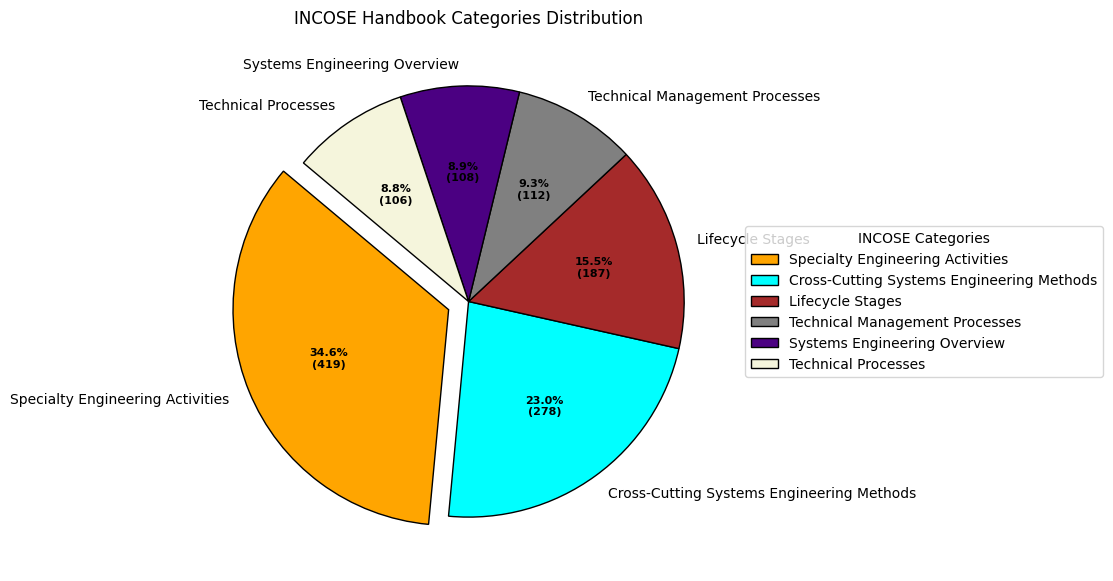

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Group the data by 'INCOSE Category' and count occurrences
category_counts = expanded_df['INCOSE Category'].value_counts()

# Data for the pie chart
categories = category_counts.index
data = category_counts.values

# Colors for the pie chart
colors = ['orange', 'cyan', 'brown', 'grey', 'indigo', 'beige'][:len(categories)]

# Exploding the first slice for better visualization
explode = [0.1 if i == 0 else 0 for i in range(len(categories))]

# Wedge properties
wp = {'linewidth': 1, 'edgecolor': 'black'}

# Custom function to display both percentages and absolute counts
def func(pct, allvalues):
    absolute = int(round(pct / 100. * np.sum(allvalues)))
    return f"{pct:.1f}%\n({absolute:d})"

# Create the pie chart
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    data,
    labels=categories,
    autopct=lambda pct: func(pct, data),
    explode=explode,
    colors=colors,
    startangle=140,
    wedgeprops=wp,
    textprops=dict(color="black")
)

# Adding legend
ax.legend(
    wedges, categories,
    title="INCOSE Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Styling the text
plt.setp(autotexts, size=8, weight="bold")
ax.set_title("INCOSE Handbook Categories Distribution")

# Display the chart
plt.show()


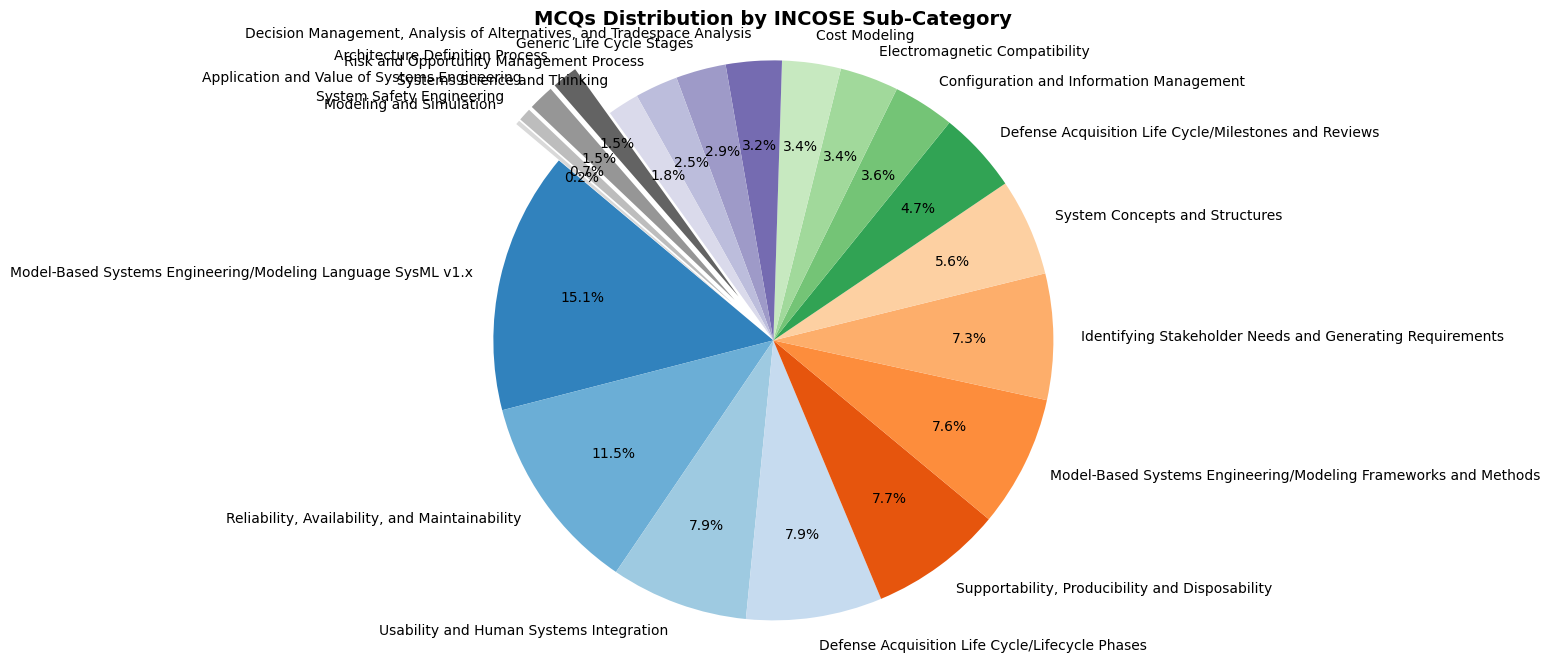

In [8]:
import matplotlib.pyplot as plt

# Group the data by 'INCOSE Sub-Category' and count occurrences
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Data for the pie chart
subcategories = subcategory_counts.index
subcategories_values = subcategory_counts.values

# Dynamically exploding smaller slices (slices with < 10% of the total)
explode = [0.2 if v < max(subcategories_values) * 0.1 else 0 for v in subcategories_values]

# Create the pie chart
plt.figure(figsize=(12, 8))
plt.pie(
    subcategories_values, 
    labels=subcategories, 
    autopct='%1.1f%%',  # Display percentages
    startangle=140,  # Start angle for better orientation
    explode=explode,  # Explode smaller slices
    pctdistance=0.7,  # Distance of percentage text
    colors=plt.cm.tab20c.colors[:len(subcategories)],  # Use a colormap for diverse colors
)

# Add a title
plt.title("MCQs Distribution by INCOSE Sub-Category", fontsize=14, weight='bold')

# Equal aspect ratio ensures the pie is drawn as a circle
plt.axis("equal")

# Show the plot
plt.show()


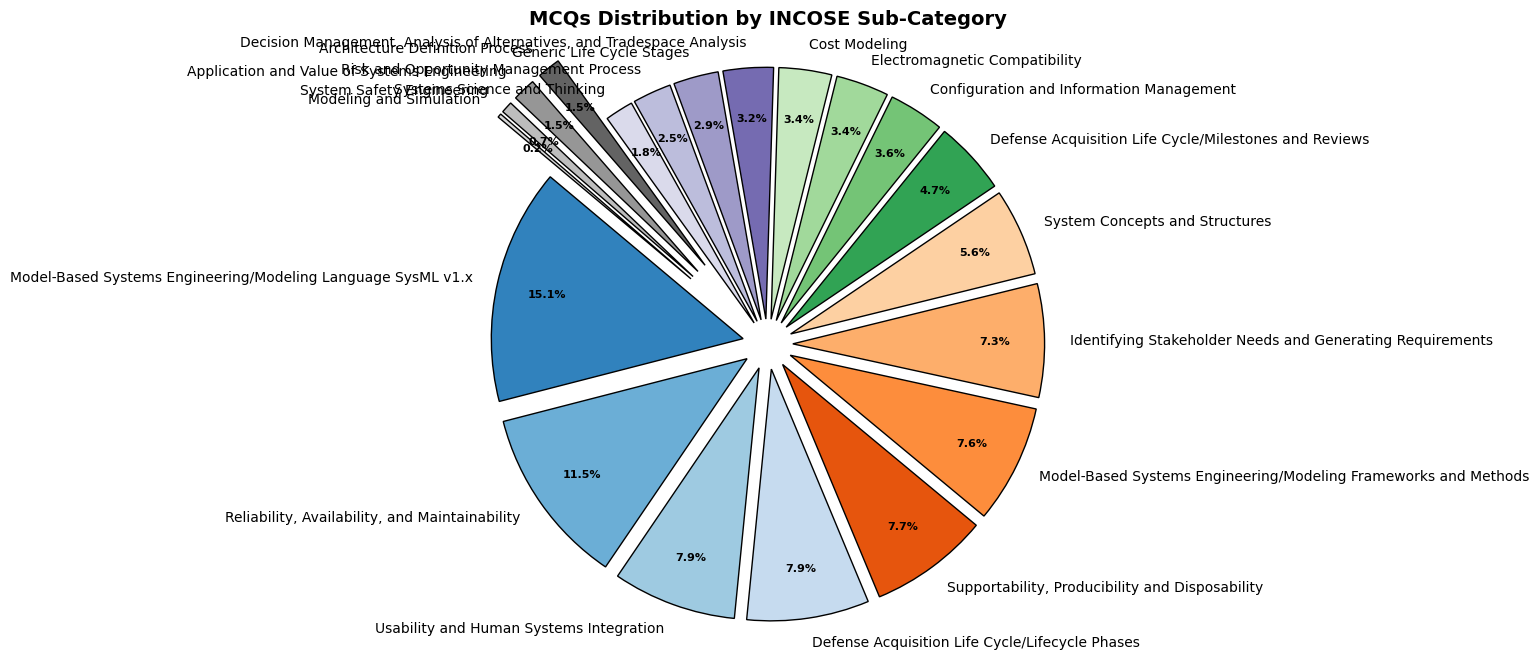

In [9]:
import matplotlib.pyplot as plt

# Group the data by 'INCOSE Sub-Category' and count occurrences
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Data for the pie chart
subcategories = subcategory_counts.index
subcategories_values = subcategory_counts.values

# Dynamically exploding smaller slices (slices with < 10% of the total)
# Increase the explode distance for smaller slices to reduce label overlap
explode = [0.4 if v < max(subcategories_values) * 0.1 else 0.1 for v in subcategories_values]

# Create the pie chart
plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(
    subcategories_values, 
    labels=subcategories, 
    autopct='%1.1f%%',  # Display percentages
    startangle=140,  # Start angle for better orientation
    explode=explode,  # Explode smaller slices
    pctdistance=0.8,  # Distance of percentage text
    labeldistance=1.1,  # Distance of labels from the center
    colors=plt.cm.tab20c.colors[:len(subcategories)],  # Use a colormap for diverse colors
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'},  # Add a border for clarity
)

# Style the text
plt.setp(autotexts, size=8, weight="bold")
plt.setp(texts, size=10)

# Add a title
plt.title("MCQs Distribution by INCOSE Sub-Category", fontsize=14, weight='bold')

# Equal aspect ratio ensures the pie is drawn as a circle
plt.axis("equal")

# Show the plot
plt.show()


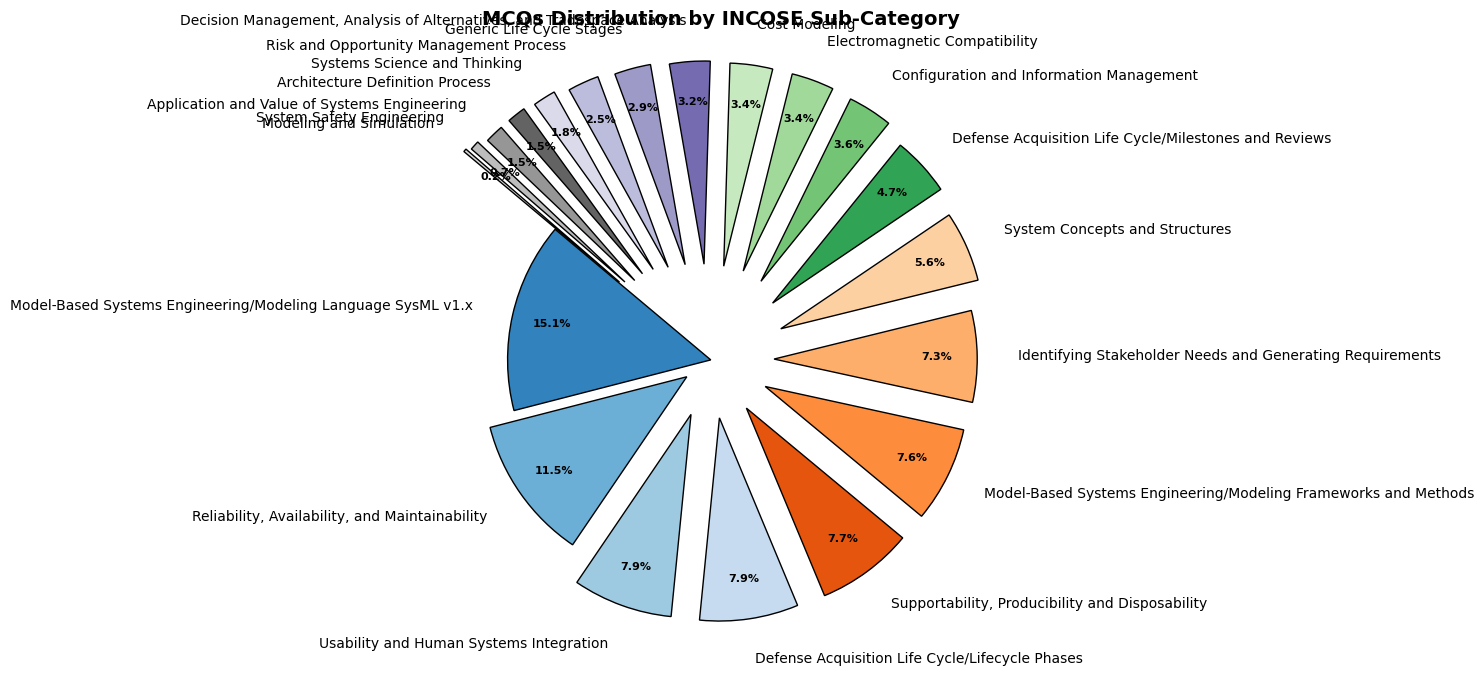

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Group the data by 'INCOSE Sub-Category' and count occurrences
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Data for the pie chart
subcategories = subcategory_counts.index
subcategories_values = subcategory_counts.values

# Dynamically calculate explode values proportional to the inverse of category sizes
max_value = max(subcategories_values)
explode = [0.6 * (max_value - v) / max_value for v in subcategories_values]

# Create the pie chart
plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(
    subcategories_values, 
    labels=subcategories, 
    autopct='%1.1f%%',  # Display percentages
    startangle=140,  # Start angle for better orientation
    explode=explode,  # Dynamically explode slices
    pctdistance=0.8,  # Distance of percentage text
    labeldistance=1.2,  # Distance of labels from the center
    colors=plt.cm.tab20c.colors[:len(subcategories)],  # Use a colormap for diverse colors
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'},  # Add a border for clarity
)

# Style the text
plt.setp(autotexts, size=8, weight="bold")
plt.setp(texts, size=10)

# Add a title
plt.title("MCQs Distribution by INCOSE Sub-Category", fontsize=14, weight='bold')

# Equal aspect ratio ensures the pie is drawn as a circle
plt.axis("equal")

# Show the plot
plt.show()


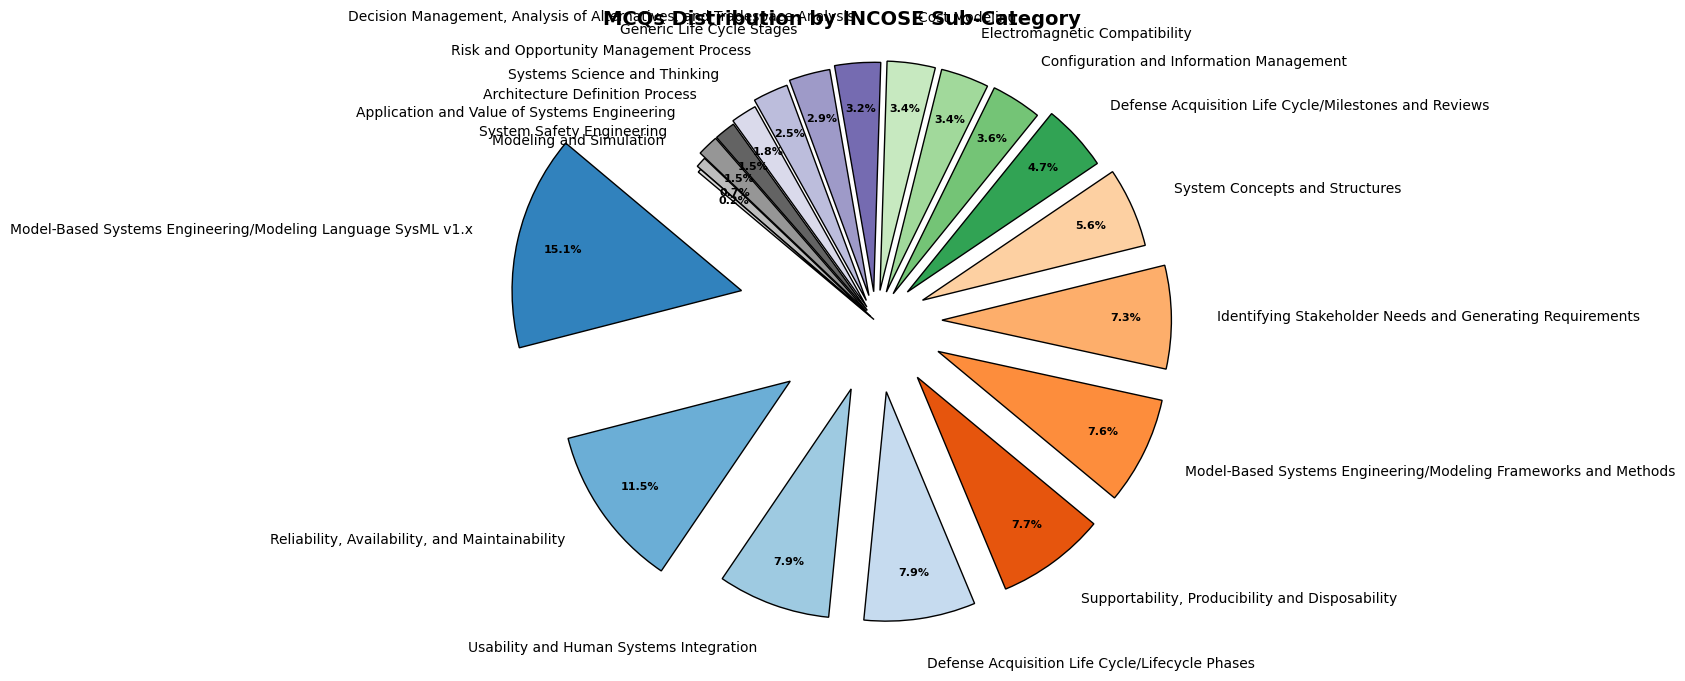

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Group the data by 'INCOSE Sub-Category' and count occurrences
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Data for the pie chart
subcategories = subcategory_counts.index
subcategories_values = subcategory_counts.values

# Dynamically calculate explode values proportional to the category sizes
max_value = max(subcategories_values)
explode = [0.6 * (v / max_value) for v in subcategories_values]

# Create the pie chart
plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(
    subcategories_values, 
    labels=subcategories, 
    autopct='%1.1f%%',  # Display percentages
    startangle=140,  # Start angle for better orientation
    explode=explode,  # Dynamically explode slices
    pctdistance=0.8,  # Distance of percentage text
    labeldistance=1.2,  # Distance of labels from the center
    colors=plt.cm.tab20c.colors[:len(subcategories)],  # Use a colormap for diverse colors
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'},  # Add a border for clarity
)

# Style the text
plt.setp(autotexts, size=8, weight="bold")
plt.setp(texts, size=10)

# Add a title
plt.title("MCQs Distribution by INCOSE Sub-Category", fontsize=14, weight='bold')

# Equal aspect ratio ensures the pie is drawn as a circle
plt.axis("equal")

# Show the plot
plt.show()


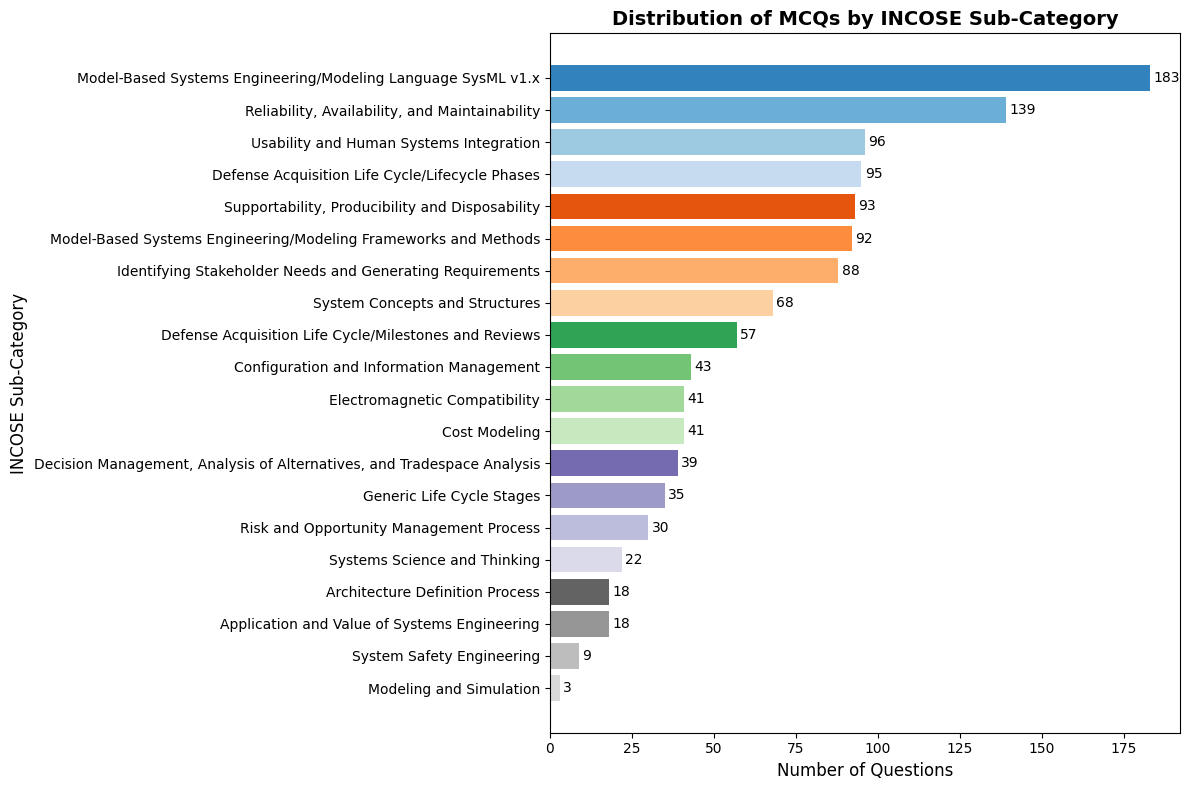

In [6]:
import matplotlib.pyplot as plt

# Data preparation
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()
subcategories = subcategory_counts.index
subcategories_values = subcategory_counts.values

# Horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(subcategories, subcategories_values, color=plt.cm.tab20c.colors[:len(subcategories)])

# Add labels and title
plt.xlabel('Number of Questions', fontsize=12)
plt.ylabel('INCOSE Sub-Category', fontsize=12)
plt.title('Distribution of MCQs by INCOSE Sub-Category', fontsize=14, weight='bold')

# Add value annotations
for i, v in enumerate(subcategories_values):
    plt.text(v + 1, i, str(v), fontsize=10, va='center')

plt.gca().invert_yaxis()  # Invert y-axis to have the largest bar on top
plt.tight_layout()
plt.show()


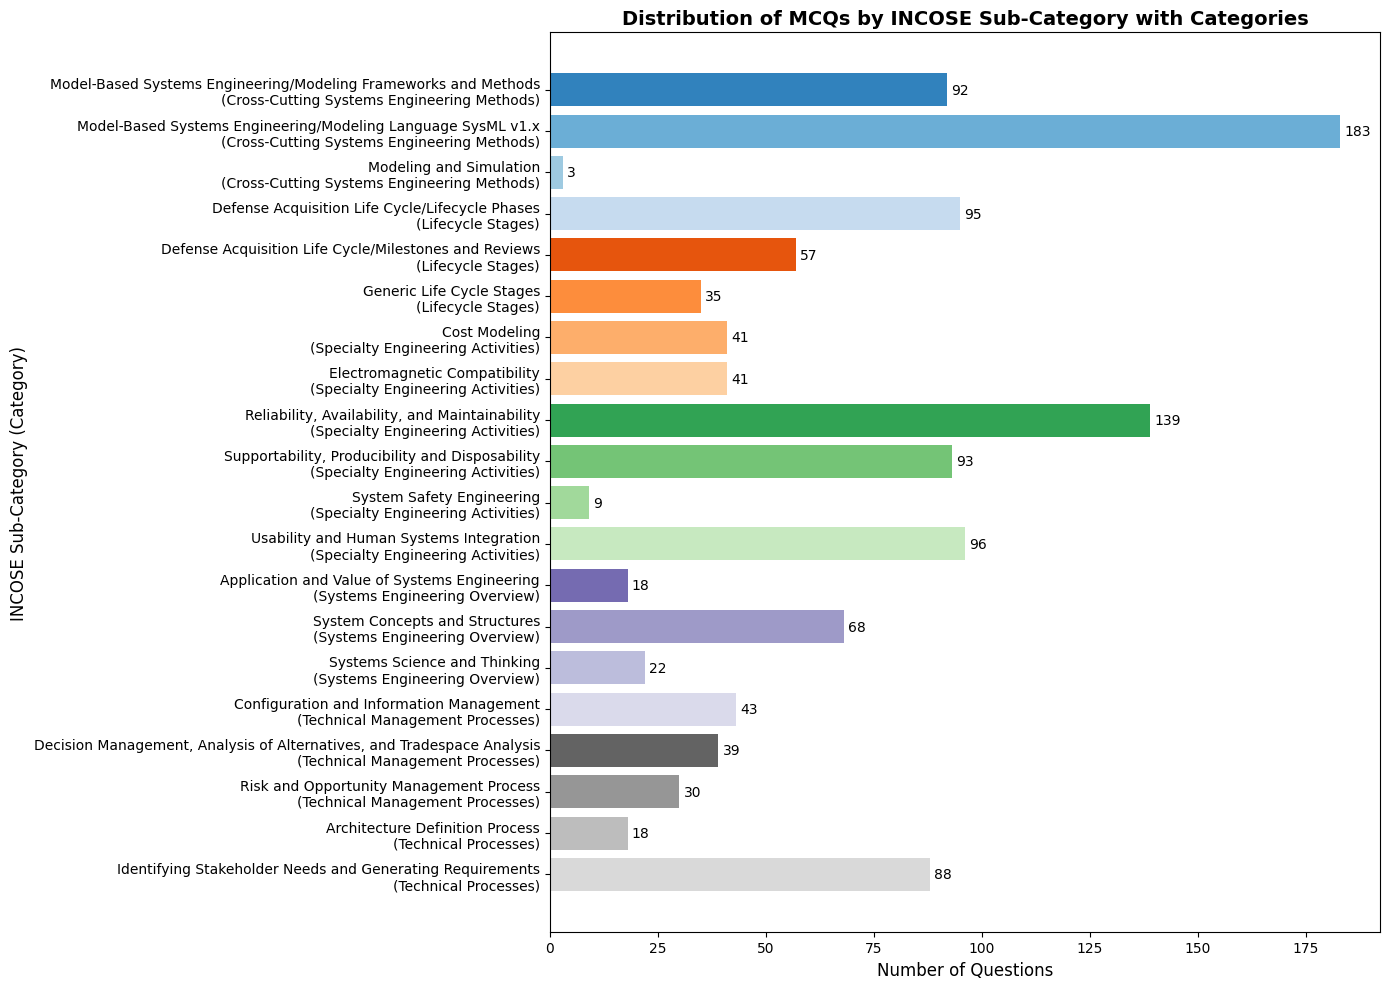

In [22]:
import matplotlib.pyplot as plt

# Group the data by 'INCOSE Category' and 'INCOSE Sub-Category'
subcategory_counts = expanded_df.groupby(['INCOSE Category', 'INCOSE Sub-Category']).size()

# Extract categories and subcategories
categories = subcategory_counts.index.get_level_values(0)
subcategories = subcategory_counts.index.get_level_values(1)
subcategory_values = subcategory_counts.values

# Combine category and subcategory for y-axis labels
y_labels = [f"{subcategory}\n({category})" for subcategory, category in zip(subcategories, categories)]

# Horizontal bar chart
plt.figure(figsize=(14, 10))
plt.barh(y_labels, subcategory_values, color=plt.cm.tab20c.colors[:len(subcategories)])

# Add labels and title
plt.xlabel('Number of Questions', fontsize=12)
plt.ylabel('INCOSE Sub-Category (Category)', fontsize=12)
plt.title('Distribution of MCQs by INCOSE Sub-Category with Categories', fontsize=14, weight='bold')

# Add value annotations
for i, v in enumerate(subcategory_values):
    plt.text(v + 1, i, str(v), fontsize=10, va='center')

# Invert y-axis to have the largest bar on top
plt.gca().invert_yaxis()

# Adjust layout to fit everything
plt.tight_layout()
plt.show()


In [7]:
### THE NEXT VERSION OF THIS ONE COULD INCLUDE STACKED BARS FOR TEXTUAL VS NUMERICAL OR BY LEVEL OF DIFFICULTY.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Group the data by 'INCOSE Category' and 'INCOSE Sub-Category'
subcategory_counts = expanded_df.groupby(['INCOSE Category', 'INCOSE Sub-Category']).size()

# Extract categories and subcategories
categories = subcategory_counts.index.get_level_values(0)
subcategories = subcategory_counts.index.get_level_values(1)
subcategory_values = subcategory_counts.values

# Unique INCOSE categories for color mapping
unique_categories = categories.unique()

# Create a color map for the categories
color_map = {category: plt.cm.tab20c(i / len(unique_categories)) for i, category in enumerate(unique_categories)}

# Assign colors to subcategories based on their parent category
bar_colors = [color_map[category] for category in categories]

# Horizontal bar chart
# plt.figure(figsize=(14, 10))
plt.figure(figsize=(10, 12), dpi=600)
plt.barh(subcategories, subcategory_values, color=bar_colors)

# Add labels and title
plt.xlabel('Number of Questions', fontsize=12)
plt.ylabel('Subcategory', fontsize=12)
# plt.title('Distribution of MCQs by INCOSE Sub-Category with Category Legend', fontsize=14, weight='bold')

# Add value annotations
for i, v in enumerate(subcategory_values):
    plt.text(v + 1, i, str(v), fontsize=10, va='center')

# Invert y-axis to have the largest bar on top
plt.gca().invert_yaxis()

# Add vertical grid lines
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust x-axis limit to ensure the largest bar fits
plt.xlim(0, 200)

# Create a legend for the categories
legend_handles = [mpatches.Patch(color=color_map[category], label=category) for category in unique_categories]
# plt.legend(handles=legend_handles, title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.legend(
    handles=legend_handles,
    title="Categories",
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),  # Centered above the plot
    fontsize=10,
    ncol=3,  # Arrange items in a single row
    frameon=False
)
# Adjust layout to fit everything
plt.tight_layout()
plt.show()


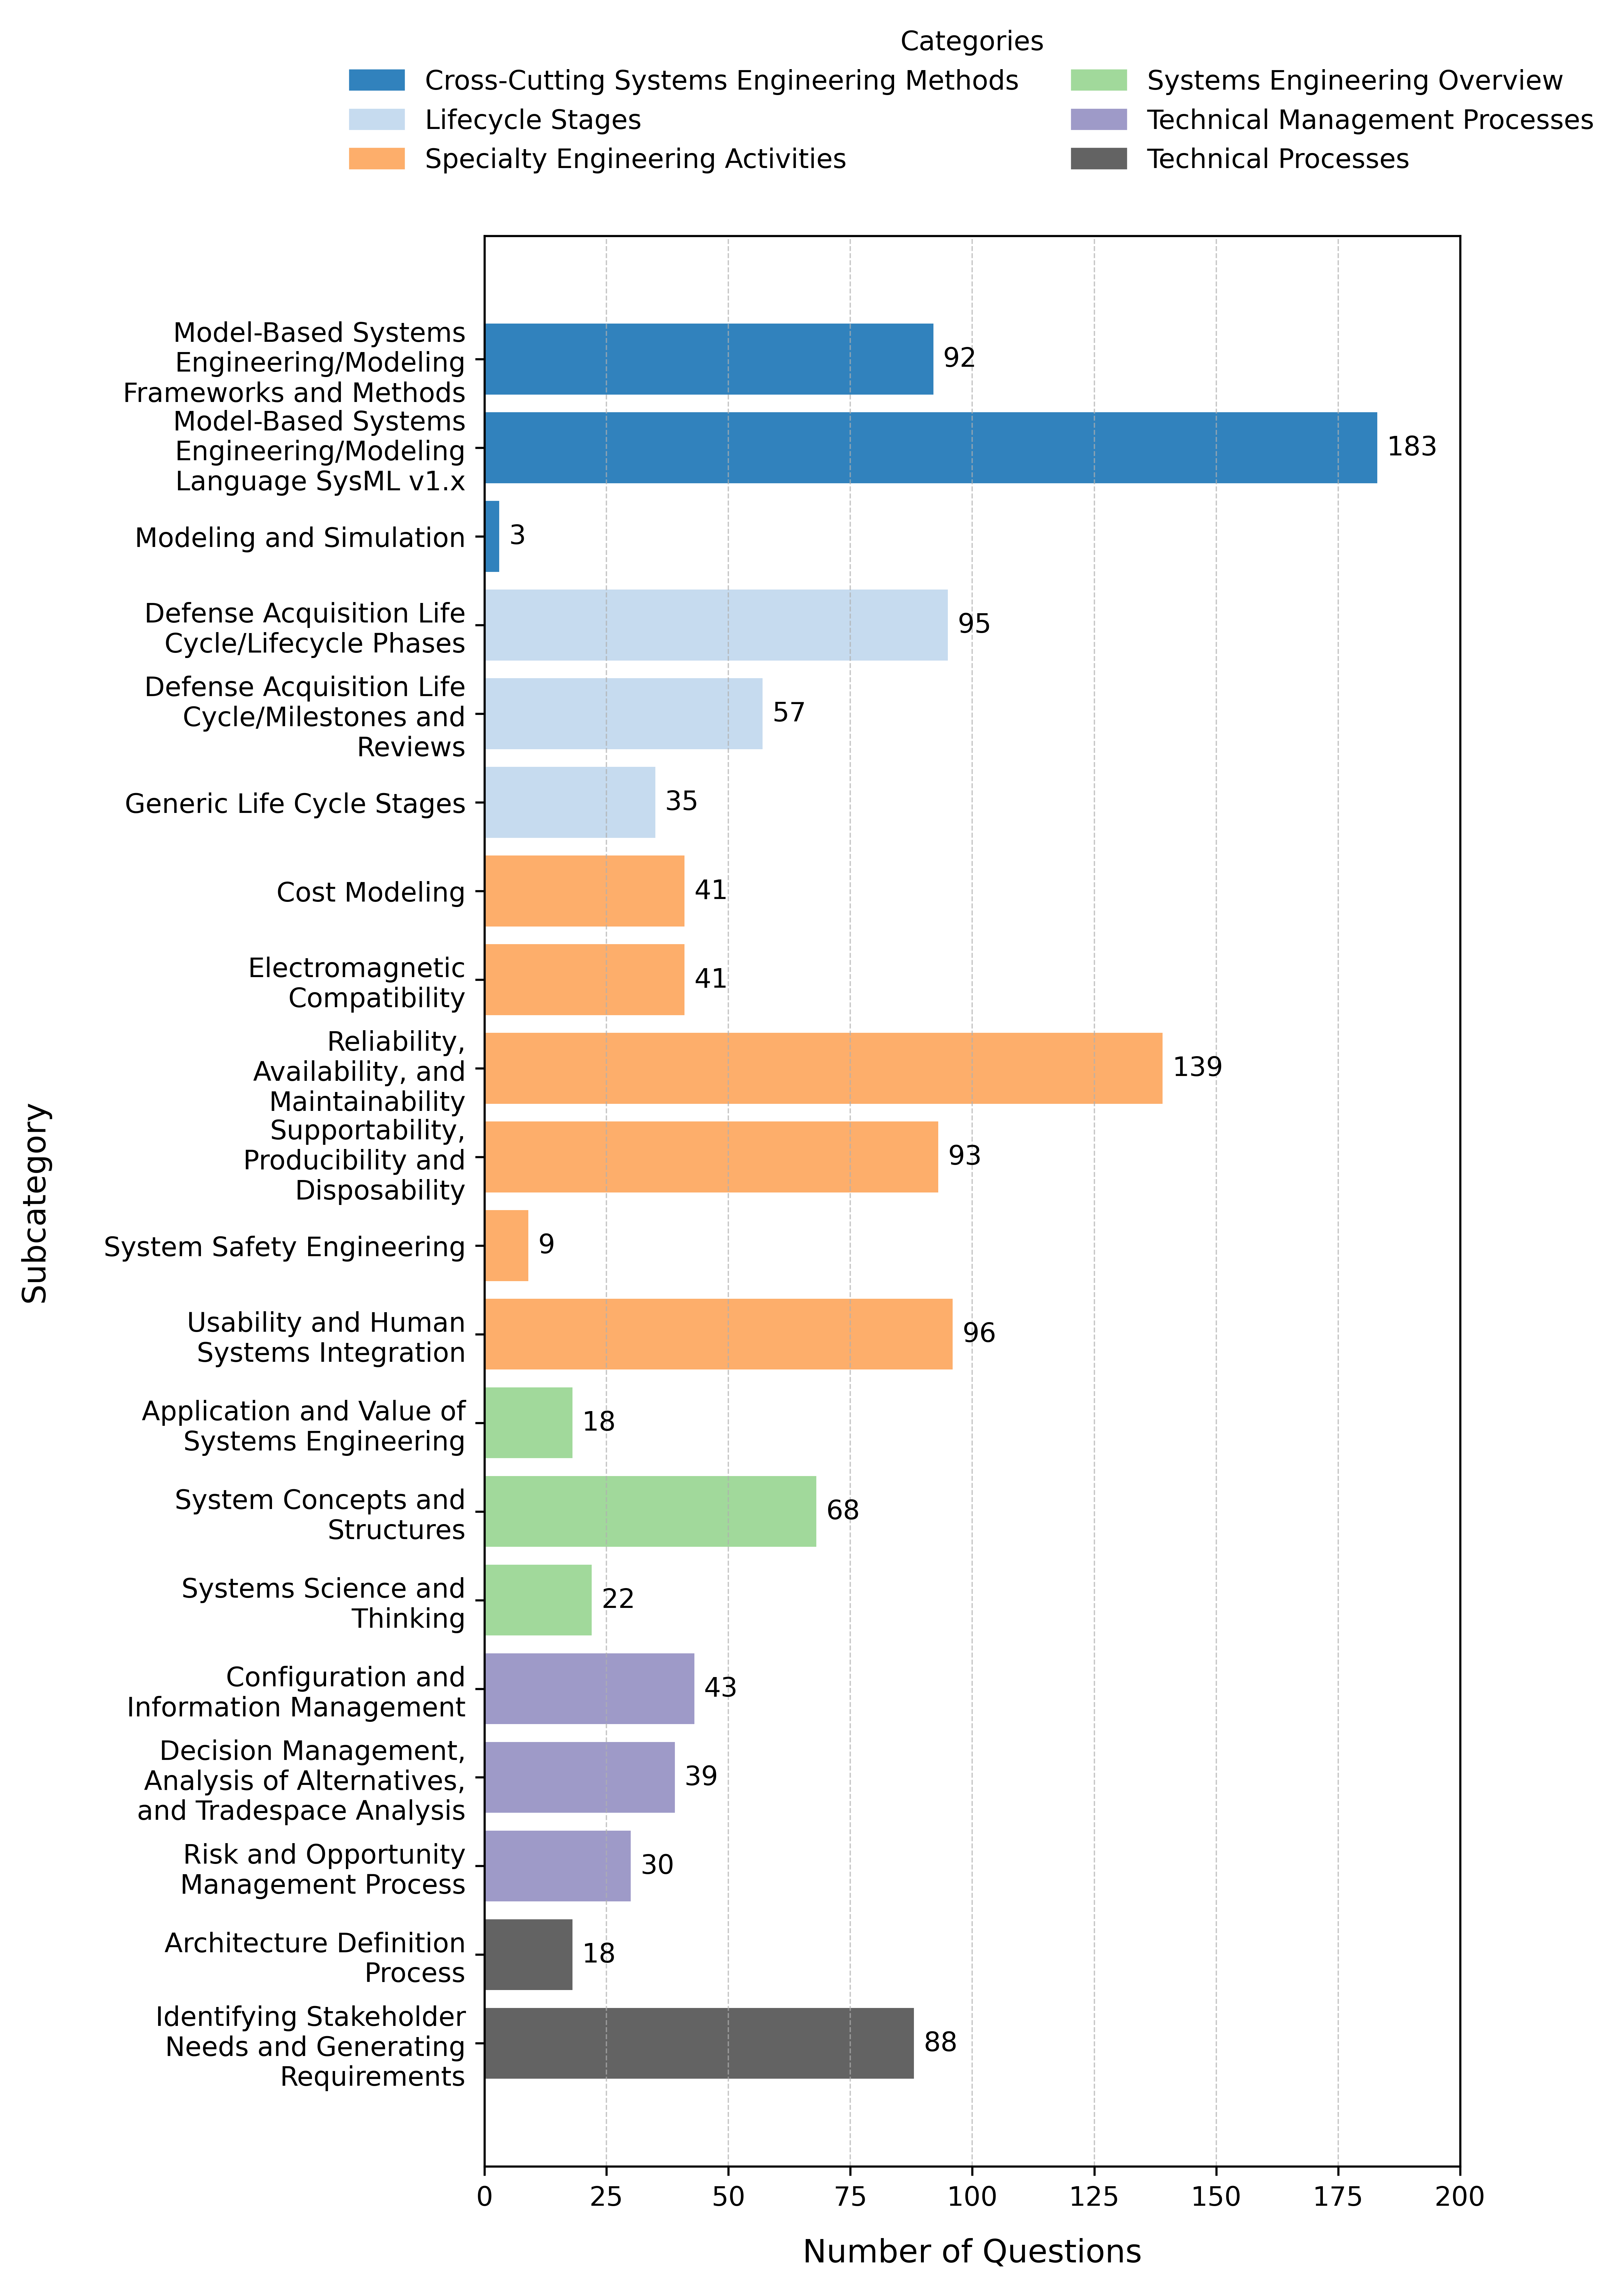

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

# Group the data by 'INCOSE Category' and 'INCOSE Sub-Category'
subcategory_counts = expanded_df.groupby(['INCOSE Category', 'INCOSE Sub-Category']).size()

# Extract categories and subcategories
categories = subcategory_counts.index.get_level_values(0)
subcategories = subcategory_counts.index.get_level_values(1)
subcategory_values = subcategory_counts.values

# Unique INCOSE categories for color mapping
unique_categories = categories.unique()

# Create a color map for the categories
color_map = {category: plt.cm.tab20c(i / len(unique_categories)) for i, category in enumerate(unique_categories)}

# Assign colors to subcategories based on their parent category
bar_colors = [color_map[category] for category in categories]

# Function to wrap y-axis labels
def wrap_labels(labels, width=20):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

wrapped_subcategories = wrap_labels(subcategories, width=25)  # Wrap labels at 20 characters

# Horizontal bar chart
plt.figure(figsize=(8, 12), dpi=600)  # Reduce width from 10 to 7
plt.barh(wrapped_subcategories, subcategory_values, color=bar_colors)

# Add labels and title
plt.xlabel('Number of Questions', fontsize=12, labelpad=10)  # Extra padding for spacing
plt.ylabel('Subcategory', fontsize=12, labelpad=20)  # Increased padding for y-axis label

# Add value annotations
for i, v in enumerate(subcategory_values):
    plt.text(v + 2, i, str(v), fontsize=10, va='center')  # Slight right shift for readability

# Invert y-axis to have the largest bar on top
plt.gca().invert_yaxis()

# Add vertical grid lines
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

# Explicitly set x-axis limits
plt.xlim(0, 200)

# Create a legend for the categories
legend_handles = [mpatches.Patch(color=color_map[category], label=category) for category in unique_categories]

plt.legend(
    handles=legend_handles,
    title="Categories",
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),  # Centered above the plot
    fontsize=10,
    ncol=2,  # Arrange items in a single row
    frameon=False
)

# Adjust layout to fit everything
plt.tight_layout()
plt.show()


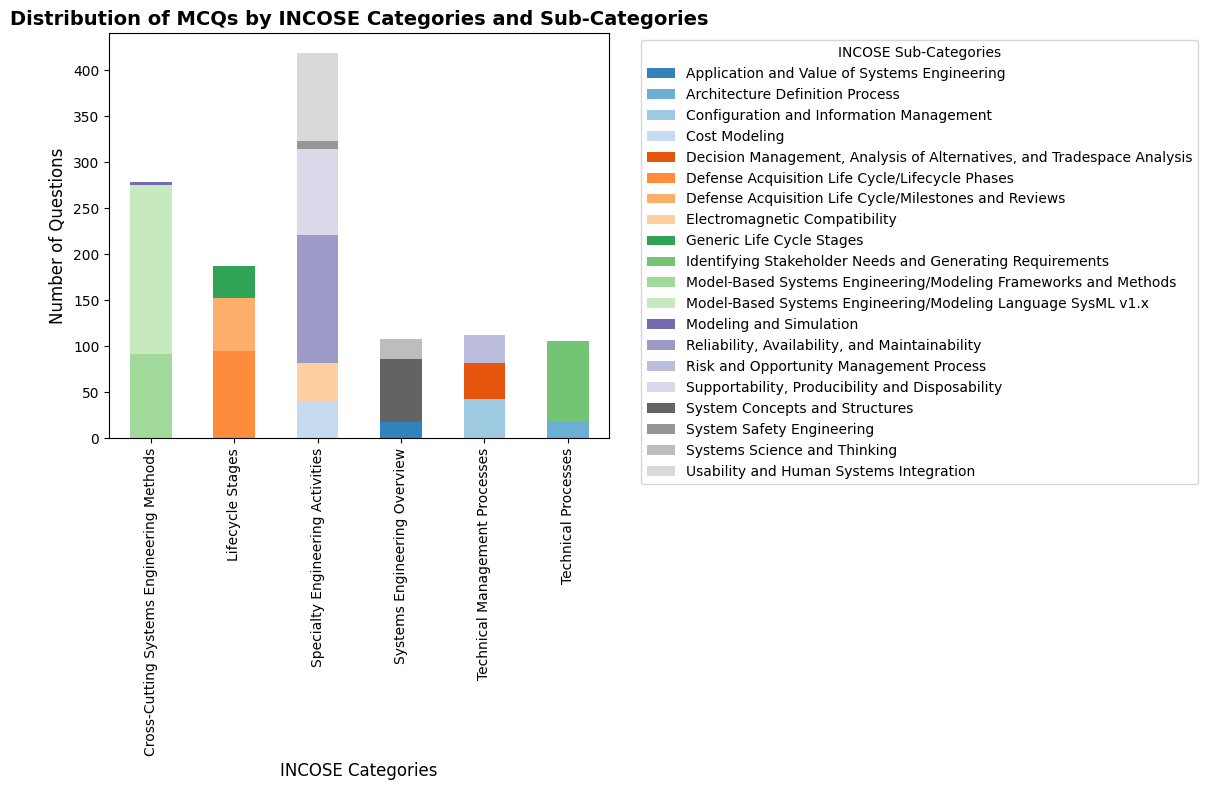

In [13]:
import pandas as pd

# Group data by 'INCOSE Category' and 'INCOSE Sub-Category'
category_subcategory_counts = expanded_df.groupby(['INCOSE Category', 'INCOSE Sub-Category']).size().unstack(fill_value=0)

# Stacked bar chart
category_subcategory_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='tab20c'
)

# Add labels and title
plt.xlabel('INCOSE Categories', fontsize=12)
plt.ylabel('Number of Questions', fontsize=12)
plt.title('Distribution of MCQs by INCOSE Categories and Sub-Categories', fontsize=14, weight='bold')

plt.legend(title='INCOSE Sub-Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


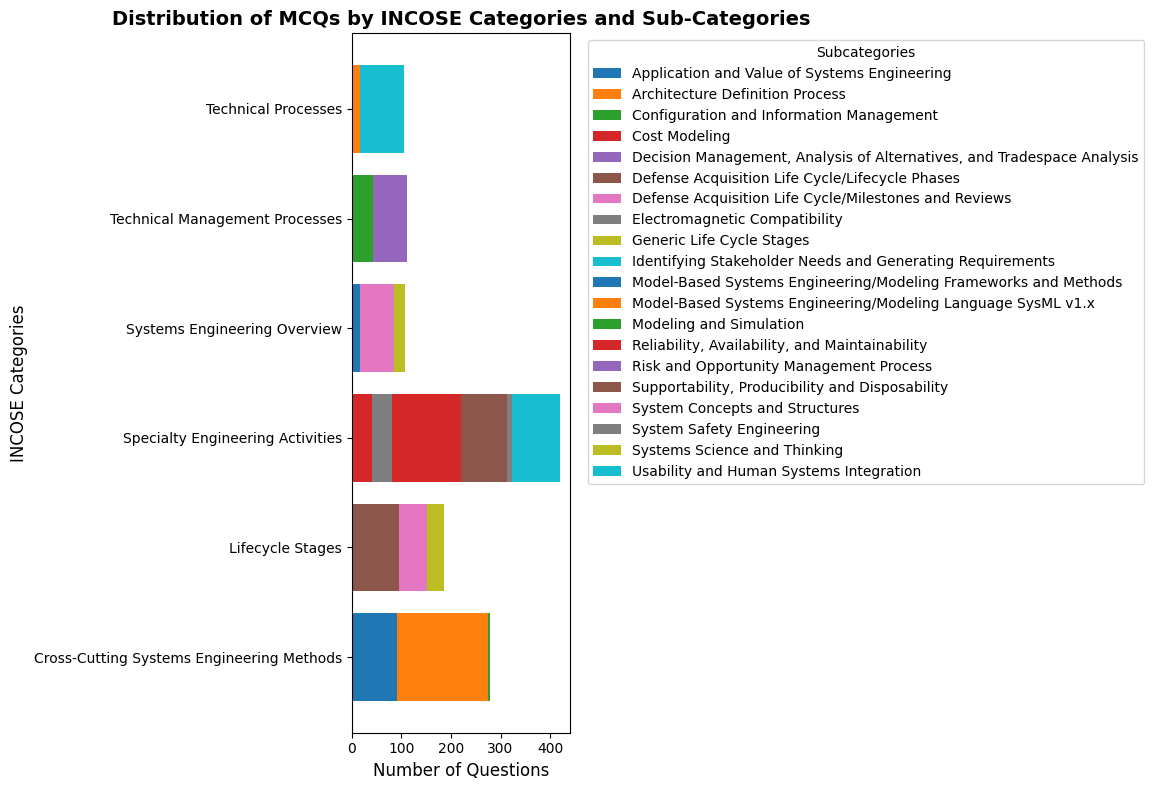

In [19]:
import matplotlib.pyplot as plt

# Group data by 'INCOSE Category' and 'INCOSE Sub-Category'
category_subcategory_counts = expanded_df.groupby(['INCOSE Category', 'INCOSE Sub-Category']).size().unstack(fill_value=0)

# Data preparation
categories = category_subcategory_counts.index
subcategories = category_subcategory_counts.columns

# Plot the horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
bar_positions = range(len(categories))

# Create a horizontal stacked bar for each subcategory
for i, subcategory in enumerate(subcategories):
    ax.barh(
        bar_positions,
        category_subcategory_counts[subcategory],
        label=subcategory,
        left=category_subcategory_counts.iloc[:, :i].sum(axis=1)  # Cumulative sum for stacking
    )

# Add labels and title
ax.set_yticks(bar_positions)
ax.set_yticklabels(categories, fontsize=10)
ax.set_xlabel('Number of Questions', fontsize=12)
ax.set_ylabel('INCOSE Categories', fontsize=12)
ax.set_title('Distribution of MCQs by INCOSE Categories and Sub-Categories', fontsize=14, weight='bold')

# Add legend
ax.legend(title='Subcategories', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adjust layout to fit everything
plt.tight_layout()
plt.show()


In [15]:
!pip install squarify


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


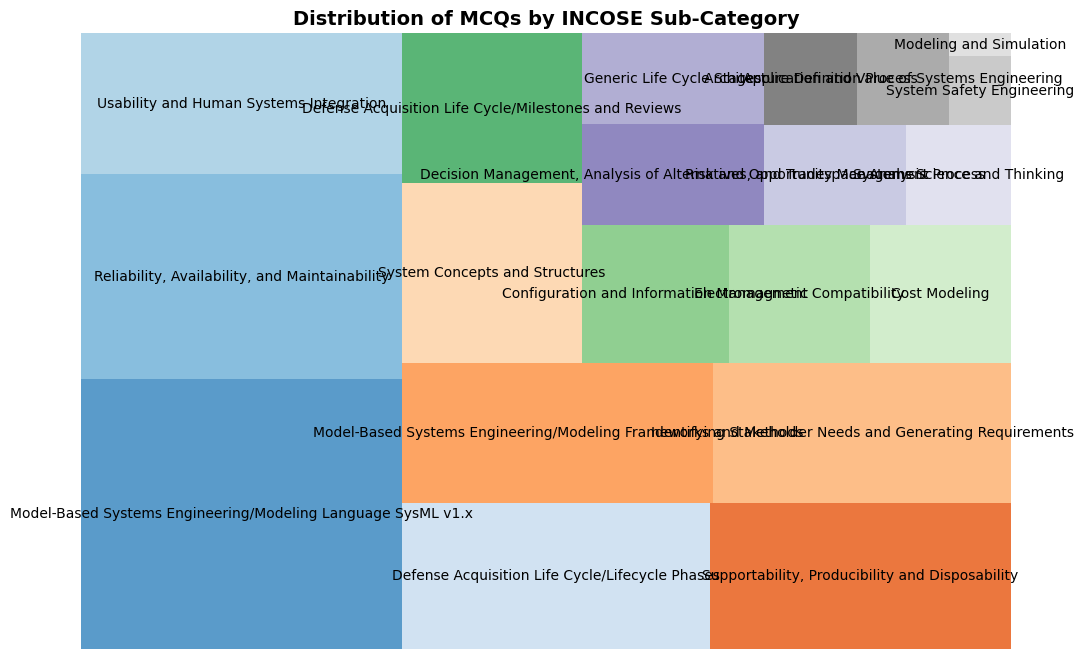

In [17]:
import squarify

# Data preparation
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Treemap
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=subcategory_counts.values,
    label=subcategory_counts.index,
    color=plt.cm.tab20c.colors[:len(subcategory_counts)],
    alpha=0.8
)

# Add title
plt.title('Distribution of MCQs by INCOSE Sub-Category', fontsize=14, weight='bold')
plt.axis('off')  # Hide axes
plt.show()


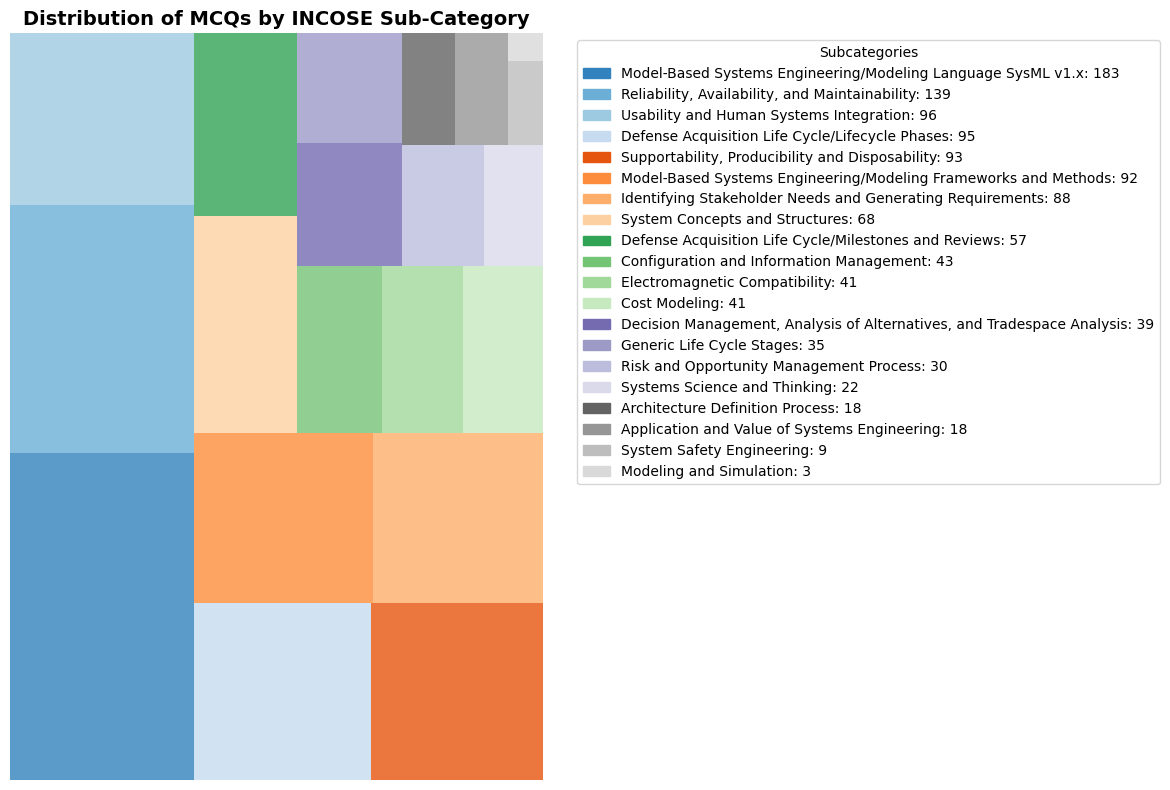

In [18]:
import matplotlib.pyplot as plt
import squarify

# Data preparation
subcategory_counts = expanded_df['INCOSE Sub-Category'].value_counts()

# Treemap
plt.figure(figsize=(12, 8))
colors = plt.cm.tab20c.colors[:len(subcategory_counts)]

# Plot treemap without labels
squarify.plot(
    sizes=subcategory_counts.values,
    color=colors,
    alpha=0.8
)

# Add title
plt.title('Distribution of MCQs by INCOSE Sub-Category', fontsize=14, weight='bold')
plt.axis('off')  # Hide axes

# Add a legend
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(len(subcategory_counts))]
labels = [f"{subcategory}: {count}" for subcategory, count in zip(subcategory_counts.index, subcategory_counts.values)]

plt.legend(
    handles,
    labels,
    title="Subcategories",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

plt.tight_layout()
plt.show()
